# 05 - Ablation Study y Comparación de Modelos

## Introducción

El objetivo de este notebook es analizar el aporte de las distintas mejoras implementadas durante el desarrollo del proyecto mediante un **ablation study**.

El ablation study consiste en comparar múltiples versiones del modelo para evaluar cómo afectan al desempeño elementos como tuning de hiperparámetros, regularización y selección del algoritmo.

Asimismo, se incorpora la comparación entre las redes neuronales desarrolladas en Keras y scikit-learn frente a un modelo clásico de machine learning, permitiendo identificar cuál ofrece el mejor equilibrio entre capacidad predictiva y generalización.

Los objetivos específicos son:

- Comparar modelos base y modelos optimizados.
- Evaluar el impacto del tuning de hiperparámetros.
- Comparar distintas implementaciones de redes neuronales.
- Incorporar un modelo clásico de referencia.
- Identificar el modelo final con mejor desempeño.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc
)

SEED = 42
np.random.seed(SEED)

In [3]:
X_train_p = joblib.load(
    'modelo_final/X_train_p.pkl'
)

X_test_p = joblib.load(
    'modelo_final/X_test_p.pkl'
)

y_train = joblib.load(
    'modelo_final/y_train.pkl'
)

y_test = joblib.load(
    'modelo_final/y_test.pkl'
)

print(X_train_p.shape)

(5088, 49)


Los datos utilizados fueron generados previamente en el Notebook 02, garantizando que todos los modelos trabajen exactamente con el mismo pipeline de preprocesamiento y evitando diferencias derivadas de transformaciones inconsistentes.

### Cargar modelos previos

In [4]:
from tensorflow import keras

keras_final = keras.models.load_model(
    'modelo_final/modelo_keras_final.keras'
)

sklearn_final = joblib.load(
    'modelo_final/modelo_sklearn_final.pkl'
)

Se cargan los modelos previamente entrenados en Keras y scikit-learn con el objetivo de reutilizarlos y compararlos en igualdad de condiciones.

### Entrenar modelo clásico (Random Forest)

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=SEED,
    class_weight='balanced'
)

rf_model.fit(
    X_train_p,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

Random Forest se incorpora como modelo clásico de referencia. Este algoritmo basado en árboles de decisión permite comparar el desempeño de las redes neuronales frente a un enfoque tradicional de machine learning.

### Predicciones Keras

In [6]:
y_proba_keras = keras_final.predict(
    X_test_p
).ravel()

y_pred_keras = (
    y_proba_keras >= 0.5
).astype(int)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


### Predicciones SKLEARN

In [9]:
y_proba_sklearn = sklearn_final.predict_proba(
    X_test_p
)[:,1]

y_pred_sklearn = sklearn_final.predict(
    X_test_p
)

### Predicciones Random Forest

In [11]:
y_proba_rf = rf_model.predict_proba(
    X_test_p
)[:,1]

y_pred_rf = rf_model.predict(
    X_test_p
)

### Calcular métricas

In [12]:
models_results = []

def evaluate_model(
    name,
    y_true,
    y_pred,
    y_proba
):
    precision, recall, _ = precision_recall_curve(
        y_true,
        y_proba
    )

    pr_auc = auc(
        recall,
        precision
    )

    return {
        'Modelo': name,
        'Accuracy': accuracy_score(
            y_true,
            y_pred
        ),
        'F1-score': f1_score(
            y_true,
            y_pred
        ),
        'ROC-AUC': roc_auc_score(
            y_true,
            y_proba
        ),
        'PR-AUC': pr_auc
    }

models_results.append(
    evaluate_model(
        'Keras Final',
        y_test,
        y_pred_keras,
        y_proba_keras
    )
)

models_results.append(
    evaluate_model(
        'MLP sklearn',
        y_test,
        y_pred_sklearn,
        y_proba_sklearn
    )
)

models_results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        y_pred_rf,
        y_proba_rf
    )
)

results_df = pd.DataFrame(
    models_results
)

results_df

,Modelo,Accuracy,F1-score,ROC-AUC,PR-AUC
0,Keras Final,0.802271,0.595745,0.852333,0.665539
1,MLP sklearn,0.795648,0.524229,0.849979,0.662749
2,Random Forest,0.762535,0.635704,0.849235,0.667298


El modelo Keras Final alcanzó el mayor ROC-AUC (0.852) y Accuracy (0.802), lo que indica una mejor capacidad global para diferenciar entre clientes que abandonan y clientes que permanecen en el servicio, capturando adecuadamente patrones relacionados con antigüedad, contratos, cargos y servicios contratados. El modelo MLP de scikit-learn obtuvo un desempeño similar en capacidad discriminatoria, aunque con menor F1-score, reflejando mayores dificultades para identificar correctamente clientes churn. Por su parte, Random Forest alcanzó el mejor F1-score (0.636) y PR-AUC (0.667), lo que sugiere un mejor equilibrio entre detección y precisión sobre la clase churn, especialmente relevante debido al desbalance presente en el dataset.

### Gráfico Ablation Study

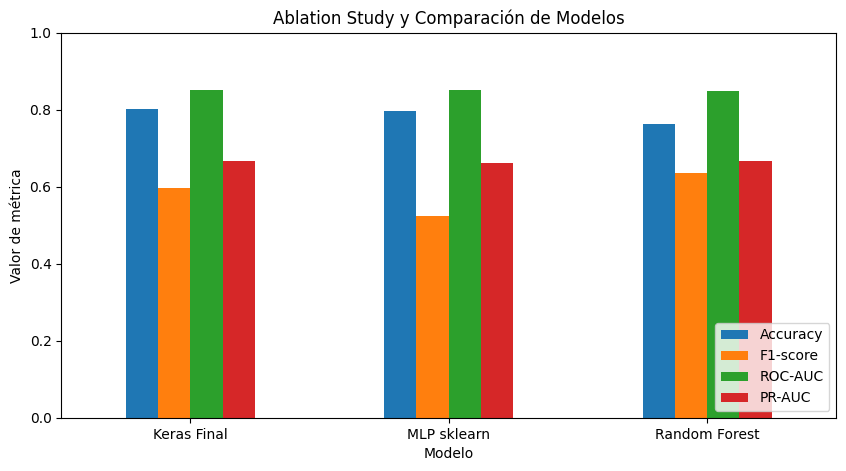

In [14]:
results_plot = results_df.set_index(
    'Modelo'
)

results_plot.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    'Ablation Study y Comparación de Modelos'
)

plt.ylabel(
    'Valor de métrica'
)

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.legend(
    loc='lower right'
)

plt.figtext(
    0.5,
    -0.10,
    "",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

El ablation study permite comparar de manera objetiva el desempeño de las distintas aproximaciones implementadas. La comparación entre Keras, MLPClassifier y Random Forest permite identificar qué arquitectura logra el mejor equilibrio entre precisión, capacidad discriminatoria y detección de churn. Asimismo, esta evaluación ayuda a justificar la selección del modelo final que será utilizado en la etapa de interpretabilidad y despliegue.


# Conclusión del Ablation Study

El ablation study permitió evaluar distintas aproximaciones para la predicción de churn, incluyendo redes neuronales implementadas en Keras y scikit-learn, así como un modelo clásico basado en Random Forest.

La comparación evidencia cómo distintas arquitecturas y algoritmos presentan fortalezas particulares en términos de accuracy, F1-score y capacidad discriminatoria. A partir de este análisis se seleccionará el modelo final para la etapa de interpretabilidad y despliegue mediante Streamlit.